In [ ]:
import re

texto = r"""João acessou o site https://www.exemplo.com.br
 para verificar seus dados cadastrais. Durante o processo, ele também visitou http://teste.org
 e https://sub.dominio.net/path?query=1
. Seu CPF informado foi 123.456.789-00, mas ele também encontrou registros antigos com o número 98765432100.

Maria, por outro lado, utilizou o portal https://login.site.com/login
 para atualizar suas informações. No sistema, seu CPF estava salvo como 111.222.333-44. Em outro documento, apareceu como 11122233344.

Além disso, foram encontrados alguns links inválidos como htt://erro.com e www.site-sem-protocolo.com
, que podem ou não ser considerados dependendo da validação. Outro CPF listado incorretamente foi 000.000.000-00."""


#Extrair CPF

In [ ]:
#(\d{3}\.?){3}\-\d{2}
#(\d{3}\.?){3}-\?\d{2}
cpf_regex = r"\d{3}\.?\d{3}\.?\d{3}-?\d{2}"
busca_CPF = re.findall(cpf_regex, texto)
print(busca_CPF)

['123.456.789-00', '98765432100', '111.222.333-44', '11122233344', '000.000.000-00']


#Extrair URL

In [ ]:
url_regex = r"(?:https?://)?(?:[\w-]+\.)+[a-zA-Z]{2,}"
busca_url = re.findall(url_regex, texto)
print(busca_url)

['https://www.exemplo.com.br', 'http://teste.org', 'https://sub.dominio.net', 'https://login.site.com', 'erro.com', 'www.site-sem-protocolo.com']


In [ ]:
url_regex = r"(https?://)?([\w-]+\.)+[a-zA-Z]{2,}"

lista_url = []
busca_url = re.finditer(url_regex, texto)
for match in busca_url:
    lista_url.append(match.group(0))

print(lista_url)

['https://www.exemplo.com.br', 'http://teste.org', 'https://sub.dominio.net', 'https://login.site.com', 'erro.com', 'www.site-sem-protocolo.com']


# Verificação de senha forte
* \> 7 caracteres
* \> 0 caracteres
* \> 0 maiusculas
* \> 0 minusculas

lookahead

# Tokenizador
* lib wordcloud
* lematizar
* tokenizar
* nuvem de palavras
* Tirar stopword, números, pontuação e espaço

In [ ]:
!pip install spacy
!pip install wordcloud

In [ ]:
import spacy
import wordcloud

In [ ]:
!python -m spacy download pt_core_news_sm
import spacy
nlp = spacy.load("pt_core_news_sm")

  Using cached https://github.com/explosion/spacy-models/releases/download/pt_core_news_sm-3.8.0/pt_core_news_sm-3.8.0-py3-none-any.whl (13.0 MB)
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
texto = r"""A seleção brasileira enfrenta a França, a partir das 17h (horário de Brasília) desta quinta-feira (26), em partida amistosa que marca o início da fase final de preparação para a próxima Copa do Mundo, que será disputada no México, no Canadá e nos Estados Unidos. O confronto será realizado no Gillete Stadium, em Boston.
conquista do próximo título mundial, o técnico italiano Carlo Ancelotti afirmou, em entrevista coletiva, que enxerga o confronto como um teste importante: “Para nós, é um teste importante, contra uma equipe que pode ser favorita na Copa. Queremos mostrar uma boa atitude e qualidade”.

O treinador também declarou que uma das estrelas dos franceses, o atacante Mbappé, receberá atenção especial. “São jogadores que todos conhecem. Jogadores muito fortes, com muita qualidade. Mbappé marcou muitos gols ano passado. Agora é um rival. Temos que defender bem contra ele. É um jogador muito rápido, com qualidade, muito efetivo na finalização”.

Mesmo diante de um adversário tão desafiador, Ancelotti deixou claro que vai apostar em uma equipe ofensiva, com quatro jogadores de ataque: “Nestes meses eu tenho pensado qual é o melhor modelo de jogo para a equipe, tendo em conta as características dos jogadores. Pensamos que o modelo de jogo que queremos planejar é com quatro na frente. Contra a França, um teste importante, queremos jogar uma boa partida, controlando o jogo, tentar defender bem, que é muito importante, ter equilíbrio e jogar bem com a bola, mostrar a qualidade que os quatro da frente têm”.

Diante dos franceses o Brasil tem um desfalque certo, o zagueiro Marquinhos, que está com dores na região do quadril. Quem pode receber uma oportunidade na posição é Ibañez, do Al Ahli (Arábia Saudita). Com isso, uma possível formação para medir forças com a França é: Ederson; Wesley, Ibañez, Léo Pereira e Douglas Santos; Casemiro e Andrey Santos; Raphinha, Matheus Cunha, Vinicius Júnior e Martinelli.

Amistosos preparatórios
Antes do início da Copa, a seleção brasileira fará mais três amistosos preparatórios. O primeiro será no dia 31 de março, contra a Croácia, no Camping World Stadium, em Orlando.

Depois, o Brasil fará um jogo de despedida da torcida brasileira. A seleção enfrentará o Panamá no dia 31 de maio no estádio do Maracanã, no Rio de Janeiro. Por fim, no dia 6 de junho, uma semana antes da estreia do Brasil no Mundial, a seleção enfrenta o Egito em seu último amistoso antes da estreia. A partida será disputada no Huntington Bank Field, em Cleveland.

Brasil na Copa

O Brasil está no Grupo C do Mundial de 2026. A estreia será contra Marrocos, no dia 13 de junho no MetLife Stadium, em Nova Jersey, às 19h (horário de Brasília).

Na segunda rodada, o Brasil encara o Haiti no Lincoln Financial Field, na Filadélfia, às 22h. Já o encerramento da primeira fase está marcado para o dia 24 de junho, contra a Escócia, no Hard Rock Stadium, em Miami, às 19h.
"""

In [ ]:
import spacy

nlp = spacy.load('pt_core_news_sm')

doc = nlp(texto)

# Lematização com filtros
lista_lemas = [
    token.lemma_.lower()
    for token in doc
    if not token.is_stop
    and not token.is_punct
    and not token.is_space
    and not token.like_num
]

print(f'Quantidade de lemas: {len(lista_lemas)}')
print(lista_lemas)

Quantidade de lemas: 28
['seleção', 'brasileiro', 'enfrentar', 'frança', '17h', 'horário', 'brasília', 'quinta-feira', 'partida', 'amistoso', 'marcar', 'início', 'fase', 'preparação', 'copa', 'mundo', 'ser', 'disputar', 'méxico', 'canadá', 'estados', 'unidos', 'confronto', 'ser', 'realizar', 'gillete', 'stadium', 'boston']


In [ ]:
import collections
counter = collections.Counter(lista_lemas)
counter.most_common(10)

[('ser', 2),
 ('seleção', 1),
 ('brasileiro', 1),
 ('enfrentar', 1),
 ('frança', 1),
 ('17h', 1),
 ('horário', 1),
 ('brasília', 1),
 ('quinta-feira', 1),
 ('partida', 1)]

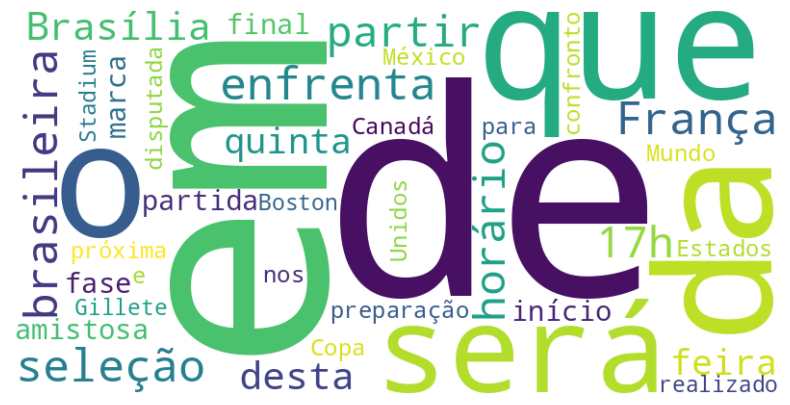

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# 2. Define any custom stop words you want to exclude (optional)
stopwords = set(STOPWORDS)
stopwords.add("tool") # Add 'tool' to the default list

# 3. Create a WordCloud object with desired parameters
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords,
    max_words=100
).generate(texto)

# 4. Display the generated image using matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Turn off the axis labels
plt.show()